# 6. KPI Analysis

This section calculates the key performance indicators required to evaluate employee engagement, burnout risk, work-life balance, satisfaction stability, and workload stress.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load updated dataset

df = pd.read_csv("../data/processed/employee_engagement_dataset.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Engagement_Index,Engagement_Category,Burnout_Risk_Score,Burnout_Risk_Level
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,0,1,6,4,0,5,2.50,Moderate,2,High
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,3,3,10,7,1,7,2.75,Moderate,0,Low
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,3,0,0,0,0,2.75,Moderate,1,Medium
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,8,7,3,0,3.25,High,1,Medium
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,3,2,2,2,2,2.50,Moderate,0,Low


In [3]:
# Check dataset shape

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1470
Columns: 35


In [4]:
# Calculate overall Engagement Index

engagement_kpi = round(df["Engagement_Index"].mean(), 2)

print("Organization Engagement Index:", engagement_kpi)

Organization Engagement Index: 2.72


In [5]:
# Calculate engagement category distribution

engagement_distribution = (
    df["Engagement_Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

engagement_distribution

Engagement_Category
Moderate    55.37
High        39.93
Low          4.69
Name: proportion, dtype: float64

In [6]:
# Calculate average Burnout Risk Score

burnout_kpi = round(df["Burnout_Risk_Score"].mean(), 2)

print("Average Burnout Risk Score:", burnout_kpi)

Average Burnout Risk Score: 0.57


In [7]:
# Calculate burnout risk distribution

burnout_distribution = (
    df["Burnout_Risk_Level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

burnout_distribution

Burnout_Risk_Level
Low       51.43
Medium    40.00
High       8.57
Name: proportion, dtype: float64

In [8]:
# Calculate Work-Life Balance Index

worklife_balance_kpi = round(
    df["WorkLifeBalance"].mean(),
    2
)

print("Work-Life Balance Index:", worklife_balance_kpi)

Work-Life Balance Index: 2.76


In [9]:
# Calculate work-life balance distribution

worklife_distribution = (
    df["WorkLifeBalance"]
    .value_counts()
    .sort_index()
)

worklife_distribution

WorkLifeBalance
1     80
2    344
3    893
4    153
Name: count, dtype: int64

In [10]:
# Define satisfaction dimensions

satisfaction_columns = [
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance"
]

In [11]:
# Calculate satisfaction variability

df["Satisfaction_Variability"] = df[
    satisfaction_columns
].std(axis=1)

df["Satisfaction_Variability"].describe()

count    1470.000000
mean        0.946417
std         0.350352
min         0.000000
25%         0.577350
50%         0.957427
75%         1.258306
max         1.732051
Name: Satisfaction_Variability, dtype: float64

In [12]:
# Calculate Satisfaction Stability Score

df["Satisfaction_Stability_Score"] = (
    100 - (df["Satisfaction_Variability"] / 1.5 * 100)
).clip(0, 100)

satisfaction_stability_kpi = round(
    df["Satisfaction_Stability_Score"].mean(),
    2
)

print(
    "Satisfaction Stability Score:",
    satisfaction_stability_kpi
)

Satisfaction Stability Score: 36.99


In [13]:
# Encode business travel intensity

travel_mapping = {
    "Non-Travel": 0,
    "Travel_Rarely": 1,
    "Travel_Frequently": 2
}

df["Travel_Intensity"] = df["BusinessTravel"].map(
    travel_mapping
)

df["Travel_Intensity"].value_counts()

Travel_Intensity
1    1043
2     277
0     150
Name: count, dtype: int64

In [14]:
# Calculate Workload Stress Indicator

df["Workload_Stress_Indicator"] = (
    df["Travel_Intensity"]
    + (df["OverTime"] == "Yes").astype(int)
)

df["Workload_Stress_Indicator"].value_counts().sort_index()

Workload_Stress_Indicator
0    115
1    783
2    486
3     86
Name: count, dtype: int64

In [15]:
# Calculate average Workload Stress Indicator

workload_stress_kpi = round(
    df["Workload_Stress_Indicator"].mean(),
    2
)

print(
    "Average Workload Stress Indicator:",
    workload_stress_kpi
)

Average Workload Stress Indicator: 1.37


In [16]:
# Create KPI summary

kpi_summary = pd.DataFrame({
    "KPI": [
        "Engagement Index",
        "Burnout Risk Score",
        "Work-Life Balance Index",
        "Satisfaction Stability Score",
        "Workload Stress Indicator"
    ],
    "Value": [
        engagement_kpi,
        burnout_kpi,
        worklife_balance_kpi,
        satisfaction_stability_kpi,
        workload_stress_kpi
    ]
})

kpi_summary

,KPI,Value
0,Engagement Index,2.72
1,Burnout Risk Score,0.57
2,Work-Life Balance Index,2.76
3,Satisfaction Stability Score,36.99
4,Workload Stress Indicator,1.37


In [17]:
# Calculate department-wise KPIs

department_kpis = df.groupby("Department").agg(
    Engagement_Index=("Engagement_Index", "mean"),
    Burnout_Risk_Score=("Burnout_Risk_Score", "mean"),
    WorkLife_Balance_Index=("WorkLifeBalance", "mean"),
    Satisfaction_Stability=("Satisfaction_Stability_Score", "mean"),
    Workload_Stress=("Workload_Stress_Indicator", "mean")
).round(2)

department_kpis

,Engagement_Index,Burnout_Risk_Score,WorkLife_Balance_Index,Satisfaction_Stability,Workload_Stress
Department,,,,,
Human Resources,2.73,0.44,2.92,38.85,1.35
Research & Development,2.73,0.59,2.73,36.87,1.37
Sales,2.71,0.55,2.82,36.98,1.37


In [18]:
# Calculate job-role-wise KPIs

role_kpis = df.groupby("JobRole").agg(
    Engagement_Index=("Engagement_Index", "mean"),
    Burnout_Risk_Score=("Burnout_Risk_Score", "mean"),
    WorkLife_Balance_Index=("WorkLifeBalance", "mean"),
    Satisfaction_Stability=("Satisfaction_Stability_Score", "mean"),
    Workload_Stress=("Workload_Stress_Indicator", "mean")
).round(2)

role_kpis


,Engagement_Index,Burnout_Risk_Score,WorkLife_Balance_Index,Satisfaction_Stability,Workload_Stress
JobRole,,,,,
Healthcare Representative,2.75,0.59,2.70,39.71,1.37
Human Resources,2.71,0.44,2.92,37.23,1.37
Laboratory Technician,2.70,0.54,2.72,36.66,1.33
Manager,2.76,0.55,2.77,36.71,1.27
Manufacturing Director,2.75,0.55,2.77,38.10,1.38
Research Director,2.67,0.52,2.86,36.84,1.36
Research Scientist,2.75,0.68,2.68,36.00,1.42
Sales Executive,2.71,0.56,2.80,36.18,1.35
Sales Representative,2.68,0.49,2.89,38.79,1.51


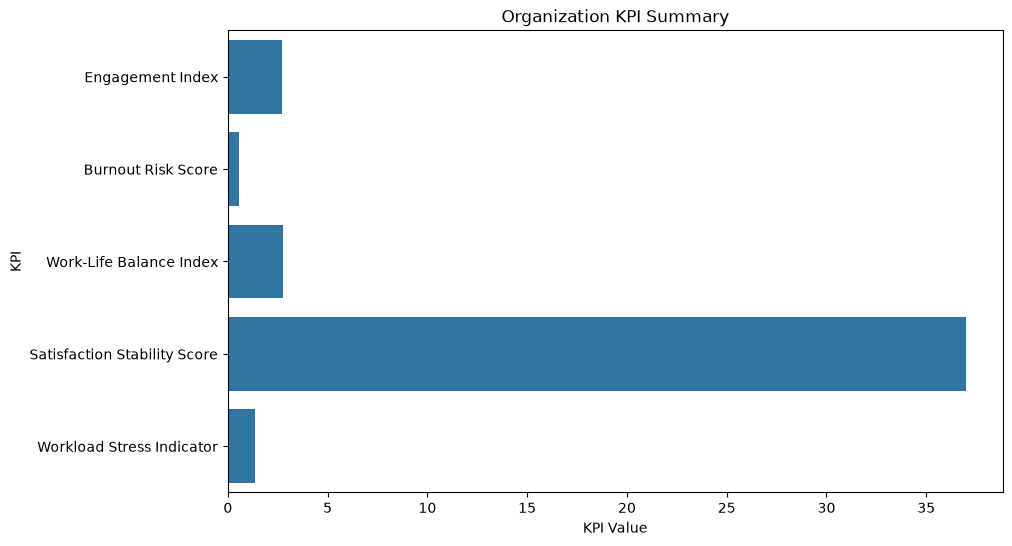

In [19]:
# Plot KPI summary

plt.figure(figsize=(10, 6))

sns.barplot(
    data=kpi_summary,
    x="Value",
    y="KPI"
)

plt.title("Organization KPI Summary")
plt.xlabel("KPI Value")
plt.ylabel("KPI")
plt.show()

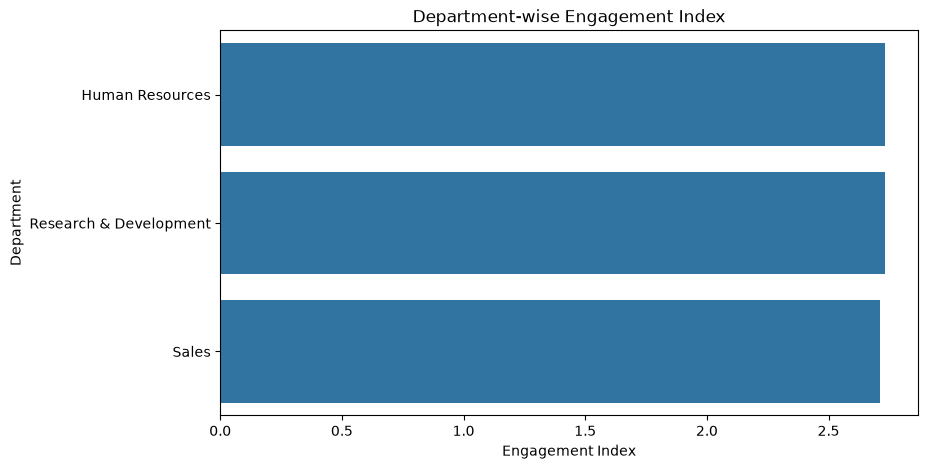

In [20]:
# Plot department engagement

department_engagement = (
    department_kpis["Engagement_Index"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=department_engagement.values,
    y=department_engagement.index
)

plt.title("Department-wise Engagement Index")
plt.xlabel("Engagement Index")
plt.ylabel("Department")
plt.show()

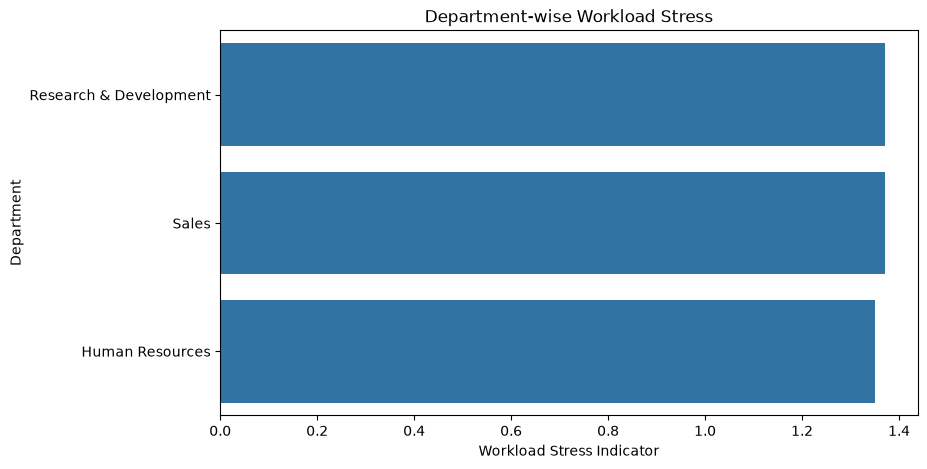

In [21]:
# Plot department workload stress

department_stress = (
    department_kpis["Workload_Stress"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=department_stress.values,
    y=department_stress.index
)

plt.title("Department-wise Workload Stress")
plt.xlabel("Workload Stress Indicator")
plt.ylabel("Department")
plt.show()

In [22]:
# Save dataset with KPI features

output_path = "../data/processed/employee_engagement_dataset.csv"

df.to_csv(output_path, index=False)

print("KPI dataset saved successfully.")
print("File:", output_path)

KPI dataset saved successfully.
File: ../data/processed/employee_engagement_dataset.csv


## Observation

The required organizational KPIs were calculated to provide a consolidated view of employee engagement, burnout risk, work-life balance, satisfaction stability, and workload stress.

The KPI analysis also provides department-level and role-level comparisons, which can be used to identify areas requiring further investigation and preventive HR intervention.